# <center>Organizaci&oacute;n de Datos</center>
#### <center>C&aacute;tedra Ing. Rodriguez, Juan Manuel </center>

## <center>Redes Neuronales</center>
### <center> Práctica RN con Keras para clasificación</center>

### Redes Neuronales con Keras - Clasificación



Import de librerias

In [ ]:
!pip install keras==2.12.0
!pip uninstall tensorflow -y
!pip install tensorflow==2.12.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 10.1 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 2.13.1
    Uninstalling keras-2.13.1:
      Successfully uninstalled keras-2.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.13.0 requires keras<2.14,>=2.13.1, but you have keras 2.12.0 which is incompatible.
Found existing installation: tensorflow 2.13.0
Uninstalling tensorflow-2.13.0:
  Successfully uninstalled tensorflow-2.13.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.9/585.9 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 75.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 40.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 10.6 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

from sklearn.metrics import f1_score,  recall_score, precision_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


import tensorflow as tf
from tensorflow import keras
# from keras.utils.vis_utils import plot_model
# import visualkeras

np.random.seed(1)
tf.random.set_seed(1)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Modelo de Redes Neuronales con Keras


### Data set Titanic

In [ ]:
dataset_ej1_orig=pd.read_csv("/content/ds_titanic.csv")

dataset_ej1_orig.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
dataset_ej1_aux=dataset_ej1_orig[['Sex','Age','Fare','Pclass','Survived']].copy()

dataset_ej1_aux.dropna(inplace=True) #Solo por simplicidad para este ejercicio!!!!!

In [ ]:
# Breve feature engineering
ej1_y_target=dataset_ej1_aux.Survived
ej1_cols_predictoras=['Sex','Age','Fare','Pclass']
ej1_x_dataset=dataset_ej1_aux[ej1_cols_predictoras]
ej1_x_dataset['Pclass'] = ej1_x_dataset['Pclass'].astype(str)

ej1_x_dataset=pd.get_dummies(ej1_x_dataset, drop_first=True)
# ej1_x_dataset.drop(columns=['Sex_male'],inplace=True)

<ipython-input-5-bcb0eaac2ce8>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ej1_x_dataset['Pclass'] = ej1_x_dataset['Pclass'].astype(str)


In [ ]:
ej1_x_dataset.head()

,Age,Fare,Sex_male,Pclass_2,Pclass_3
0,22.0,7.2500,1,0,1
1,38.0,71.2833,0,0,0
2,26.0,7.9250,0,0,1
3,35.0,53.1000,0,0,0
4,35.0,8.0500,1,0,1


In [ ]:
ej1_x_train, ej1_x_test, ej1_y_train, ej1_y_test = train_test_split(ej1_x_dataset,ej1_y_target,test_size=0.3)

In [ ]:
sscaler=StandardScaler()
sscaler.fit(pd.DataFrame(ej1_x_train[['Age','Fare']]))

StandardScaler()

In [ ]:
ej1_x_train_transform_1=sscaler.transform(pd.DataFrame(ej1_x_train[['Age','Fare']]))
ej1_x_test_transform_1=sscaler.transform(pd.DataFrame(ej1_x_test[['Age','Fare']]))

ej1_x_train.Age=ej1_x_train_transform_1[:,0]
ej1_x_train.Fare=ej1_x_train_transform_1[:,1]

ej1_x_test.Age=ej1_x_test_transform_1[:,0]
ej1_x_test.Fare=ej1_x_test_transform_1[:,1]

In [ ]:
ej1_x_train.head()

,Age,Fare,Sex_male,Pclass_2,Pclass_3
641,-0.402429,0.616739,0,0,0
433,-0.882976,-0.513543,1,0,1
202,0.284068,-0.524981,1,0,1
585,-0.814327,0.804892,0,0,0
544,1.382462,1.291637,1,0,0


$w_0 * Age + w_1 * Fare + w_2 * Sex_male + w_3 * Pclass_2 + w_4 * Pclass_3 + b$

#### Modelo

In [ ]:
# calcula la cantidad de clases
cant_clases=len(np.unique(ej1_y_train))
d_in=len(ej1_x_train.columns)

modelo_titanic_1 = keras.Sequential([
    keras.layers.Dense(1,input_shape=(d_in,)),
    keras.layers.Dense(1, activation='sigmoid')])

modelo_titanic_1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 6         
                                                                 
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 8
Trainable params: 8
Non-trainable params: 0
_________________________________________________________________


In [ ]:
modelo_titanic_1.compile(
  optimizer=keras.optimizers.SGD(learning_rate=0.01),
  loss='binary_crossentropy',
  # metricas para ir calculando en cada iteracion o batch
  metrics=['AUC'],
)

cant_epochs_titanic=100
modelo_titanic1_historia = modelo_titanic_1.fit(ej1_x_train,ej1_y_train,
                                                epochs=cant_epochs_titanic,
                                                batch_size=50,verbose=False)

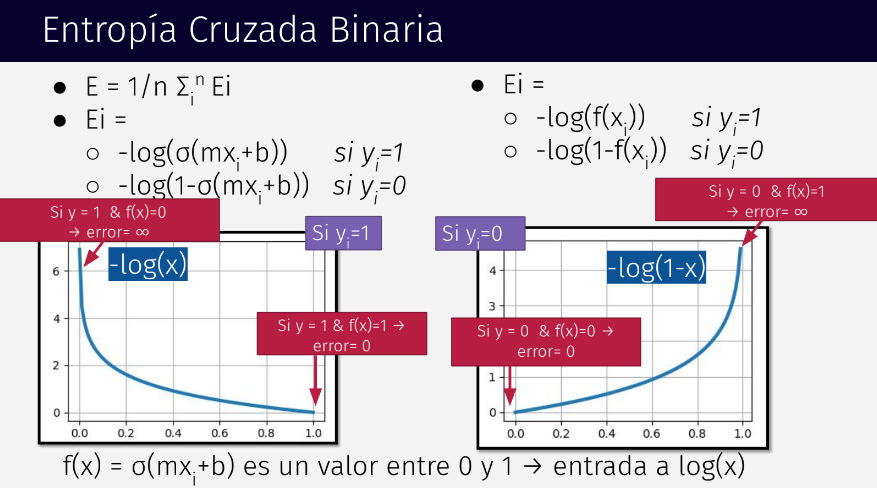

7/7 [==============================] - 0s 4ms/step


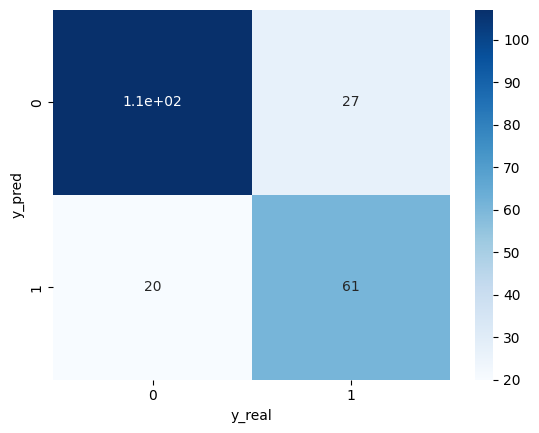

In [ ]:
y_predic_ej1 = modelo_titanic_1.predict(ej1_x_test)
y_predic_cat_ej1 = np.where(y_predic_ej1>0.4,1,0)

ds_validacion=pd.DataFrame(y_predic_cat_ej1,ej1_y_test).reset_index()
ds_validacion.columns=['y_pred','y_real']

tabla=pd.crosstab(ds_validacion.y_pred, ds_validacion.y_real)
grf=sns.heatmap(tabla,annot=True, cmap = 'Blues')
plt.show()

### Data set Iris

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import OneHotEncoder, StandardScaler

iris = load_iris()

x = iris['data']
y = iris['target']
names = iris['target_names']
feature_names = iris['feature_names']

# Split the data set into training and testing
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.5,
                                                    stratify = y,
                                                    random_state=22)

# One hot encoding
enc = OneHotEncoder()
y_train_encoder = enc.fit_transform(y_train[:, np.newaxis]).toarray()
y_test_encoder = enc.transform(y_test[:, np.newaxis]).toarray()

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
# calcula la cantidad de clases
cant_clases=len(np.unique(y))

d_in=len(feature_names)
modelo_iris_1 = keras.Sequential([
    # input_shape solo en la primer capa
    # Capa con 3 salidas, activación relu
    keras.layers.Dense(2,input_shape=(d_in,), activation='relu', kernel_initializer='uniform'),
    keras.layers.Dense(cant_clases, activation='softmax')])

modelo_iris_1.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 2)                 10        
                                                                 
 dense_3 (Dense)             (None, 3)                 9         
                                                                 
Total params: 19
Trainable params: 19
Non-trainable params: 0
_________________________________________________________________


In [ ]:
modelo_iris_1.compile(
  optimizer=keras.optimizers.SGD(learning_rate=0.001),
  loss='categorical_crossentropy',
  # metricas para ir calculando en cada iteracion o batch
  metrics=['AUC'],
)

cant_epochs=100

historia_modelo_iris_1=modelo_iris_1.fit(x_train_scaled,y_train_encoder,epochs=cant_epochs,
                                         batch_size=16,verbose=False)

In [ ]:
y_predic_iris = modelo_iris_1.predict(x_test_scaled)

3/3 [==============================] - 0s 6ms/step


In [ ]:
y_predic_iris.shape

(75, 3)

In [ ]:
y_predic_iris[0:10]

array([[0.3341579 , 0.33226398, 0.33357808],
       [0.3341579 , 0.33226398, 0.33357808],
       [0.32387105, 0.3445808 , 0.3315482 ],
       [0.31944618, 0.35328913, 0.3272647 ],
       [0.3162178 , 0.35949922, 0.324283  ],
       [0.3290288 , 0.33745614, 0.33351502],
       [0.3250117 , 0.34421998, 0.33076832],
       [0.3407711 , 0.31645167, 0.3427771 ],
       [0.3047453 , 0.37732944, 0.3179252 ],
       [0.32882243, 0.33662423, 0.33455324]], dtype=float32)

In [ ]:
y_predic_iris_clases=np.argmax(y_predic_iris,axis=1).tolist()
y_real_iris_clases=np.argmax(y_test_encoder,axis=1).tolist()

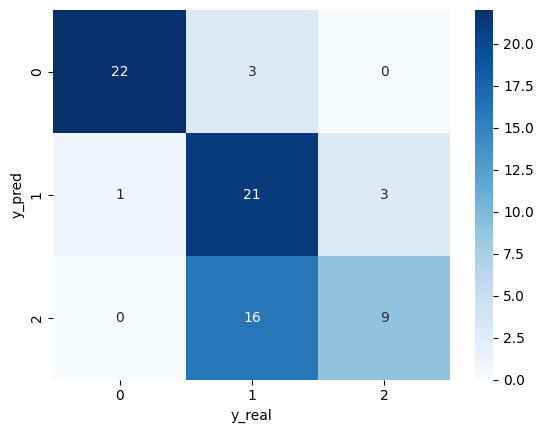

In [ ]:
ds_validacion_iris=pd.DataFrame(y_predic_iris_clases,y_real_iris_clases).reset_index()
ds_validacion_iris.columns=['y_pred','y_real']

tabla_iris=pd.crosstab(ds_validacion_iris.y_pred, ds_validacion_iris.y_real)
grf=sns.heatmap(tabla_iris,annot=True, cmap = 'Blues')
plt.show()

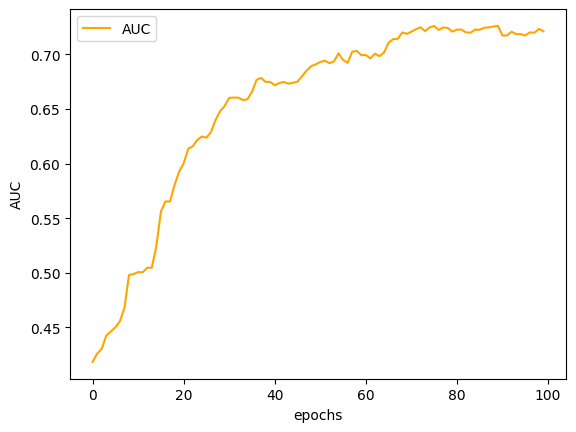

In [ ]:
epochs = range(cant_epochs)

plt.plot(epochs, historia_modelo_iris_1.history['auc'], color='orange', label='AUC')
plt.xlabel("epochs")
plt.ylabel("AUC")
plt.legend()

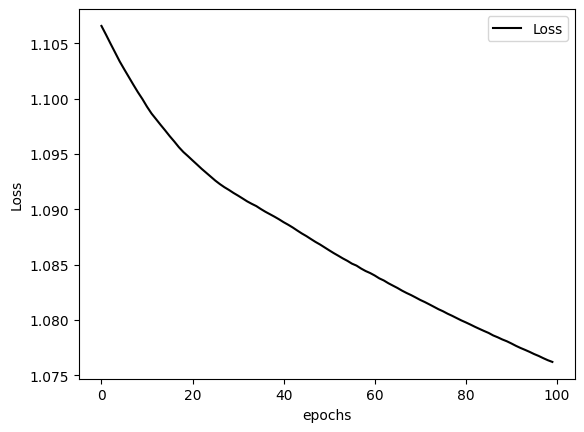

In [ ]:
epochs = range(cant_epochs)

plt.plot(epochs, historia_modelo_iris_1.history['loss'], color='black', label='Loss')
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.legend()

#### Validación cruzada

In [ ]:
from keras.wrappers.scikit_learn import KerasClassifier   #o Sci-Keras!!!

In [ ]:
# Create the sklearn model for the network

def create_model():
    modelo= keras.Sequential([
    keras.layers.Dense(2,input_shape=(d_in,), activation='relu',kernel_initializer='uniform'),
    keras.layers.Dense(cant_clases, activation='softmax')])

    modelo.compile(
      optimizer=keras.optimizers.SGD(learning_rate=0.001),
      loss='categorical_crossentropy',
      # metricas para ir calculando en cada iteracion o batch
      metrics=['AUC'],
    )

    return modelo


In [ ]:
modelo_cv = KerasClassifier(build_fn=create_model)

In [ ]:
from sklearn.model_selection import GridSearchCV

epochs = [50, 100, 150]
batches = [5, 10, 20]

param_grid = dict( epochs=epochs, batch_size=batches)

print(param_grid)

grid = GridSearchCV(estimator=modelo_cv, param_grid=param_grid)
grid_result = grid.fit(x_train_scaled, y_train_encoder)

{'epochs': [50, 100, 150], 'batch_size': [5, 10, 20]}
Epoch 1/50
12/12 [==============================] - 3s 7ms/step - loss: 1.1074 - auc: 0.4061
Epoch 2/50
12/12 [==============================] - 0s 11ms/step - loss: 1.1047 - auc: 0.4367
Epoch 3/50
12/12 [==============================] - 0s 8ms/step - loss: 1.1023 - auc: 0.4446
Epoch 4/50
12/12 [==============================] - 0s 15ms/step - loss: 1.0988 - auc: 0.5130
Epoch 5/50
12/12 [==============================] - 0s 6ms/step - loss: 1.0951 - auc: 0.5657
Epoch 6/50
12/12 [==============================] - 0s 13ms/step - loss: 1.0916 - auc: 0.6035
Epoch 7/50
12/12 [==============================] - 0s 8ms/step - loss: 1.0890 - auc: 0.6069
Epoch 8/50
12/12 [==============================] - 0s 8ms/step - loss: 1.0865 - auc: 0.6133
Epoch 9/50
12/12 [==============================] - 0s 12ms/step - loss: 1.0839 - auc: 0.6276
Epoch 10/50
12/12 [==============================] - 0s 7ms/step - loss: 1.0813 - auc: 0.6224
Epoch 11/50

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 444, in _passthrough_scorer
    return estimator.score(*args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/keras/wrappers/scikit_learn.py", line 335, in score
    raise ValueError(
ValueError: The model is not configured to compute accuracy. You should pass `metrics=["accuracy"]` to the `model.compile()` method.

  warnings.warn(


12/12 [==============================] - 1s 7ms/step - loss: 1.0936 - auc: 0.5547
Epoch 2/50
12/12 [==============================] - 0s 5ms/step - loss: 1.0883 - auc: 0.5993
Epoch 3/50
12/12 [==============================] - 0s 3ms/step - loss: 1.0824 - auc: 0.6933
Epoch 4/50
12/12 [==============================] - 0s 8ms/step - loss: 1.0772 - auc: 0.6949
Epoch 5/50
12/12 [==============================] - 0s 4ms/step - loss: 1.0726 - auc: 0.7165
Epoch 6/50
12/12 [==============================] - 0s 3ms/step - loss: 1.0681 - auc: 0.7162
Epoch 7/50
12/12 [==============================] - 0s 4ms/step - loss: 1.0639 - auc: 0.7228
Epoch 8/50
12/12 [==============================] - 0s 3ms/step - loss: 1.0598 - auc: 0.7278
Epoch 9/50
12/12 [==============================] - 0s 4ms/step - loss: 1.0557 - auc: 0.7252
Epoch 10/50
12/12 [==============================] - 0s 4ms/step - loss: 1.0516 - auc: 0.7279
Epoch 11/50
12/12 [==============================] - 0s 4ms/step - loss: 1.0476 

3/3 [==============================] - 0s 12ms/step - loss: 0.9032 - auc: 0.7756
Epoch 1/100
12/12 [==============================] - 1s 4ms/step - loss: 1.0762 - auc: 0.7381
Epoch 2/100
12/12 [==============================] - 0s 3ms/step - loss: 1.0731 - auc: 0.7579
Epoch 3/100
12/12 [==============================] - 0s 3ms/step - loss: 1.0702 - auc: 0.7683
Epoch 4/100
12/12 [==============================] - 0s 3ms/step - loss: 1.0674 - auc: 0.7780
Epoch 5/100
12/12 [==============================] - 0s 5ms/step - loss: 1.0647 - auc: 0.8032
Epoch 6/100
12/12 [==============================] - 0s 3ms/step - loss: 1.0619 - auc: 0.8044
Epoch 7/100
12/12 [==============================] - 0s 3ms/step - loss: 1.0592 - auc: 0.8079
Epoch 8/100
12/12 [==============================] - 0s 3ms/step - loss: 1.0564 - auc: 0.8172
Epoch 9/100
12/12 [==============================] - 0s 3ms/step - loss: 1.0538 - auc: 0.8194
Epoch 10/100
12/12 [==============================] - 0s 4ms/step - loss:

Se truncaron las últimas líneas 5000 del resultado de transmisión.
Epoch 63/100
6/6 [==============================] - 0s 8ms/step - loss: 1.0634 - auc: 0.5875
Epoch 64/100
6/6 [==============================] - 0s 6ms/step - loss: 1.0631 - auc: 0.5979
Epoch 65/100
6/6 [==============================] - 0s 12ms/step - loss: 1.0627 - auc: 0.5979
Epoch 66/100
6/6 [==============================] - 0s 5ms/step - loss: 1.0624 - auc: 0.5978
Epoch 67/100
6/6 [==============================] - 0s 10ms/step - loss: 1.0620 - auc: 0.6019
Epoch 68/100
6/6 [==============================] - 0s 5ms/step - loss: 1.0618 - auc: 0.6017
Epoch 69/100
6/6 [==============================] - 0s 10ms/step - loss: 1.0614 - auc: 0.6017
Epoch 70/100
6/6 [==============================] - 0s 6ms/step - loss: 1.0610 - auc: 0.6033
Epoch 71/100
6/6 [==============================] - 0s 6ms/step - loss: 1.0606 - auc: 0.6037
Epoch 72/100
6/6 [==============================] - 0s 13ms/step - loss: 1.0603 - auc: 0.6039

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:952: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Epoch 1/50
15/15 [==============================] - 1s 3ms/step - loss: 1.0967 - auc: 0.5706
Epoch 2/50
15/15 [==============================] - 0s 4ms/step - loss: 1.0952 - auc: 0.5997
Epoch 3/50
15/15 [==============================] - 0s 4ms/step - loss: 1.0937 - auc: 0.6109
Epoch 4/50
15/15 [==============================] - 0s 3ms/step - loss: 1.0921 - auc: 0.6372
Epoch 5/50
15/15 [==============================] - 0s 4ms/step - loss: 1.0905 - auc: 0.6456
Epoch 6/50
15/15 [==============================] - 0s 3ms/step - loss: 1.0892 - auc: 0.6695
Epoch 7/50
15/15 [==============================] - 0s 3ms/step - loss: 1.0880 - auc: 0.6656
Epoch 8/50
15/15 [==============================] - 0s 3ms/step - loss: 1.0869 - auc: 0.6769
Epoch 9/50
15/15 [==============================] - 0s 4ms/step - loss: 1.0858 - auc: 0.6798
Epoch 10/50
15/15 [==============================] - 0s 3ms/step - loss: 1.0849 - auc: 0.6835
Epoch 11/50
15/15 [==============================] - 0s 3ms/step - lo

In [ ]:
print("Mejor modelo: %f %s" % (grid_result.best_score_, grid_result.best_params_))

Mejor modelo: nan {'batch_size': 5, 'epochs': 50}


In [ ]:
y_predic_iris_cv =grid.predict(x_test_scaled)

3/3 [==============================] - 0s 4ms/step


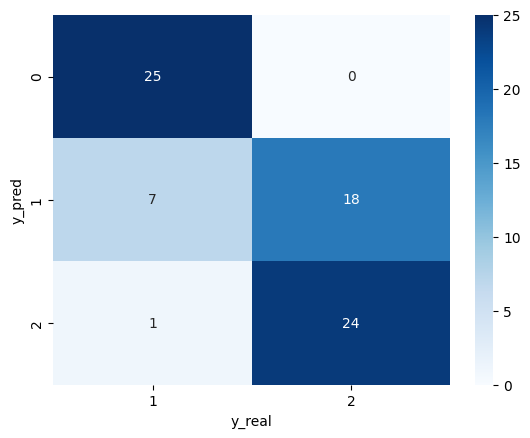

In [ ]:
ds_validacion_iris=pd.DataFrame(y_predic_iris_cv,y_test).reset_index()
ds_validacion_iris.columns=['y_pred','y_real']

tabla_iris=pd.crosstab(ds_validacion_iris.y_pred, ds_validacion_iris.y_real)
grf=sns.heatmap(tabla_iris,annot=True, cmap = 'Blues')
plt.show()